# Foro 3 - Minería de Datos
## Clase 3: Análisis Exploratorio, PCA y Clustering

En esta actividad se trabaja con un dataset de clientes para realizar análisis exploratorio de datos (EDA), reducción de dimensionalidad con PCA y segmentación con K-Means.

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Cliente": [1, 2, 3, 4, 5, 6, 7, 8],
    "Edad": [25, 40, 35, 50, 30, 45, 38, 29],
    "Ingresos": [50000, 60000, 70000, 80000, 45000, 85000, 72000, 48000],
    "Experiencia": [2, 10, 7, 15, 3, 20, 12, 4],
    "Estado_Cuenta": ["Pagado", "Moroso", "Pagado", "Moroso", "Pagado", "Moroso", "Pagado", "Pagado"]
})

df

,Cliente,Edad,Ingresos,Experiencia,Estado_Cuenta
0,1,25,50000,2,Pagado
1,2,40,60000,10,Moroso
2,3,35,70000,7,Pagado
3,4,50,80000,15,Moroso
4,5,30,45000,3,Pagado
5,6,45,85000,20,Moroso
6,7,38,72000,12,Pagado
7,8,29,48000,4,Pagado


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## 1. Análisis Exploratorio de Datos (EDA)

Primero se realiza un análisis exploratorio para observar la distribución de las variables y la relación entre ellas.

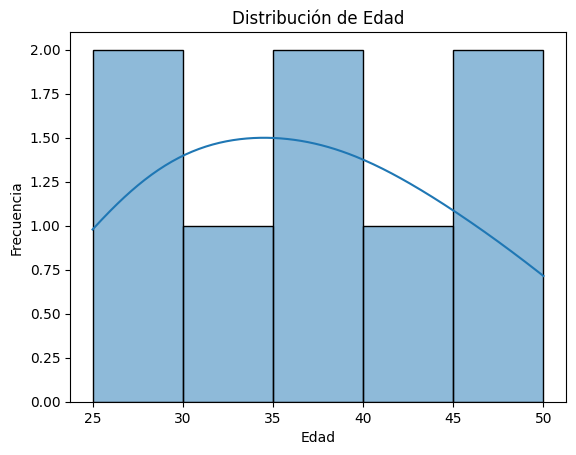

In [ ]:
sns.histplot(df["Edad"], bins=5, kde=True)
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

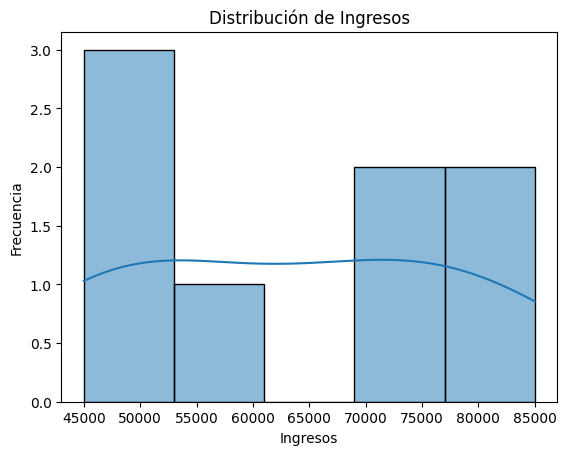

In [ ]:
sns.histplot(df["Ingresos"], bins=5, kde=True)
plt.title("Distribución de Ingresos")
plt.xlabel("Ingresos")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
correlacion = df[["Edad", "Ingresos", "Experiencia"]].corr()
correlacion

,Edad,Ingresos,Experiencia
Edad,1.00000,0.872330,0.912120
Ingresos,0.87233,1.000000,0.928305
Experiencia,0.91212,0.928305,1.000000


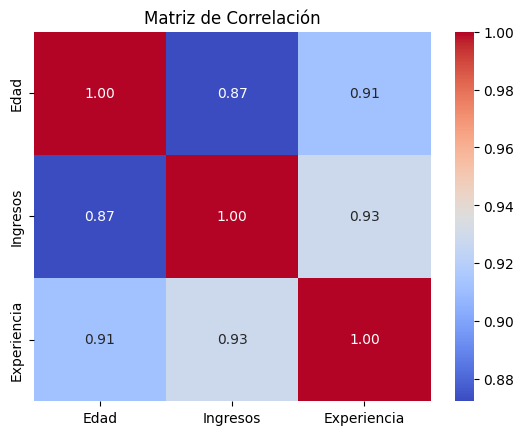

In [ ]:
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

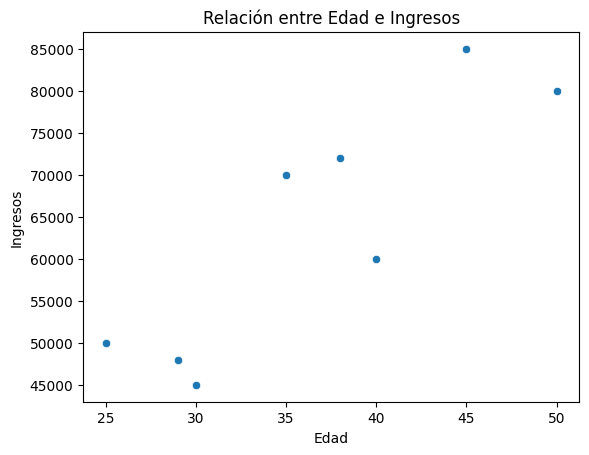

In [ ]:
sns.scatterplot(x=df["Edad"], y=df["Ingresos"])
plt.title("Relación entre Edad e Ingresos")
plt.xlabel("Edad")
plt.ylabel("Ingresos")
plt.show()

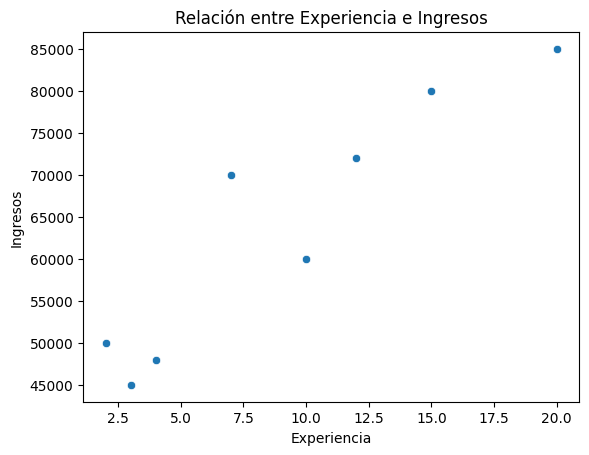

In [ ]:
sns.scatterplot(x=df["Experiencia"], y=df["Ingresos"])
plt.title("Relación entre Experiencia e Ingresos")
plt.xlabel("Experiencia")
plt.ylabel("Ingresos")
plt.show()

### Breve interpretación del EDA

A partir de los gráficos se puede observar que los ingresos y la experiencia presentan una relación positiva, ya que en general los clientes con mayor experiencia tienden a tener ingresos más altos.

También se observa una relación positiva entre edad e ingresos, aunque no tan marcada como en el caso de experiencia e ingresos.

Los histogramas permiten visualizar cómo se distribuyen los valores de edad e ingresos, mientras que la matriz de correlación ayuda a confirmar la relación entre las variables numéricas.

## 2. Aplicación de PCA

Luego del análisis exploratorio, se aplica PCA para reducir la dimensionalidad del conjunto de datos y representar la información en dos componentes principales.

In [ ]:
X = df[["Edad", "Ingresos", "Experiencia"]]
X

,Edad,Ingresos,Experiencia
0,25,50000,2
1,40,60000,10
2,35,70000,7
3,50,80000,15
4,30,45000,3
5,45,85000,20
6,38,72000,12
7,29,48000,4


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
pca_full = PCA()
pca_full.fit(X_scaled)

print("Varianza explicada por cada componente:")
print(pca_full.explained_variance_ratio_)

print("Varianza acumulada:")
print(pca_full.explained_variance_ratio_.cumsum())

Varianza explicada por cada componente:
[0.9362353  0.04299134 0.02077335]
Varianza acumulada:
[0.9362353  0.97922665 1.        ]


In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca

,PC1,PC2
0,-2.088358,-0.349258
1,0.187607,0.487469
2,-0.065374,-0.384217
3,2.210591,0.452509
4,-1.830565,0.335839
5,2.544210,-0.346833
6,0.724952,-0.281611
7,-1.683062,0.086102


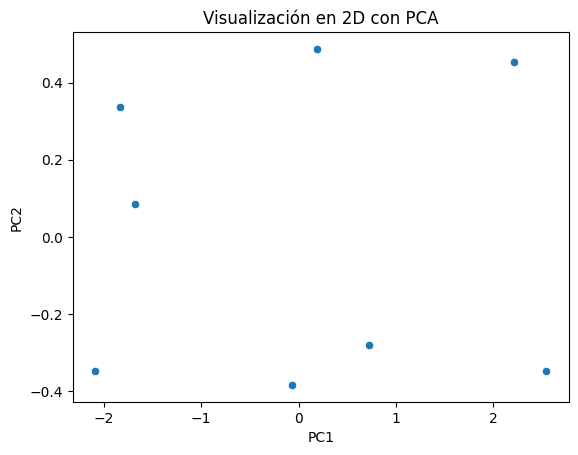

In [ ]:
sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"])
plt.title("Visualización en 2D con PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

### Interpretación de PCA

Después de normalizar los datos, se aplicó PCA para reducir las variables a dos componentes principales. Esto permitió representar los datos en un espacio de dos dimensiones y facilitar su visualización.

Las dos primeras componentes explican más del 90% de la varianza, por lo que se puede reducir la dimensionalidad sin perder información relevante.

El objetivo es conservar la mayor cantidad posible de información con menos variables, haciendo más simple el análisis de los grupos.

## 3. Segmentación de clientes con K-Means

Por último, se aplica K-Means con 3 clusters para identificar grupos de clientes con características similares, primero sobre los datos originales y luego sobre los datos transformados por PCA.

In [ ]:
kmeans_original = KMeans(n_clusters=3, random_state=42)
df["Cluster_Original"] = kmeans_original.fit_predict(X_scaled)

df[["Cliente", "Edad", "Ingresos", "Experiencia", "Cluster_Original"]]

,Cliente,Edad,Ingresos,Experiencia,Cluster_Original
0,1,25,50000,2,2
1,2,40,60000,10,0
2,3,35,70000,7,0
3,4,50,80000,15,1
4,5,30,45000,3,2
5,6,45,85000,20,1
6,7,38,72000,12,0
7,8,29,48000,4,2


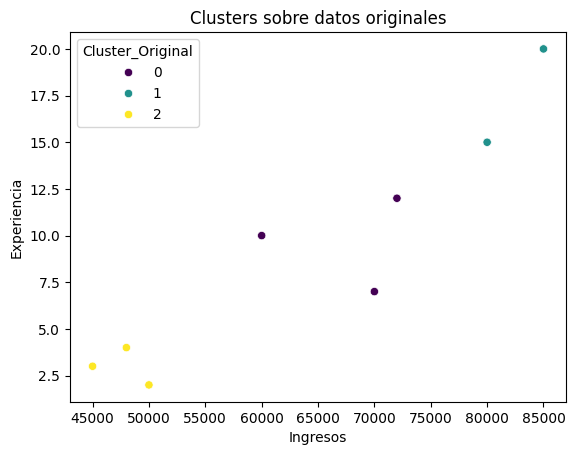

In [ ]:
sns.scatterplot(
    x=df["Ingresos"],
    y=df["Experiencia"],
    hue=df["Cluster_Original"],
    palette="viridis"
)
plt.title("Clusters sobre datos originales")
plt.xlabel("Ingresos")
plt.ylabel("Experiencia")
plt.show()

In [ ]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
df_pca["Cluster_PCA"] = kmeans_pca.fit_predict(df_pca)

df_pca

,PC1,PC2,Cluster_PCA
0,-2.088358,-0.349258,2
1,0.187607,0.487469,0
2,-0.065374,-0.384217,0
3,2.210591,0.452509,1
4,-1.830565,0.335839,2
5,2.544210,-0.346833,1
6,0.724952,-0.281611,0
7,-1.683062,0.086102,2


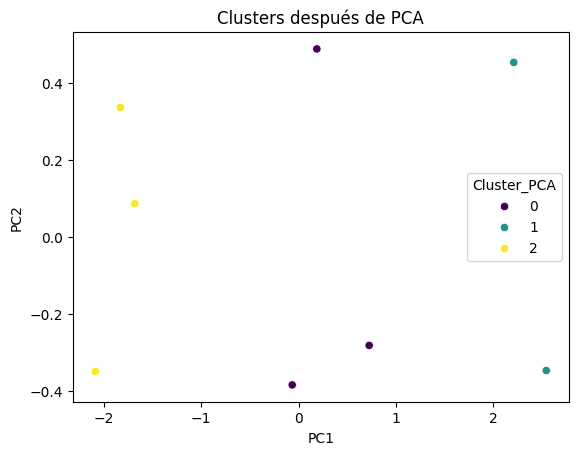

In [ ]:
sns.scatterplot(
    x=df_pca["PC1"],
    y=df_pca["PC2"],
    hue=df_pca["Cluster_PCA"],
    palette="viridis"
)
plt.title("Clusters después de PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

### Interpretación del clustering

AAl aplicar K-Means se identificaron tres grupos de clientes con perfiles diferentes. En general, se pueden distinguir clientes con ingresos y experiencia bajos, clientes intermedios y clientes con ingresos y experiencia más altos.

Después de aplicar PCA, los clusters se visualizan de forma más clara y separada en dos dimensiones, lo que facilita su interpretación y comparación.

## 4. Consulta a una herramienta de IA

Se realizó una consulta a una herramienta de IA con la siguiente pregunta:

"Tengo datos de clientes con variables de edad, ingresos y experiencia. ¿Qué técnicas avanzadas puedo usar para mejorar la segmentación?"

La herramienta sugirió probar otros métodos como DBSCAN o clustering jerárquico, además de revisar valores atípicos y evaluar la calidad de los clusters obtenidos.

Esta respuesta resulta útil porque complementa lo aprendido en clase y muestra que K-Means no es la única técnica disponible para segmentar datos.

## Conclusión

El uso de PCA permitió simplificar el análisis sin perder información importante, mientras que el clustering ayudó a identificar distintos perfiles de clientes. En conjunto, estas técnicas facilitan la toma de decisiones basada en datos.